# Problema 3 ML - Segmentacion de paises por patrones productivos

Objetivo del Negocio: Agrupar a los países en clústeres basados en su modelo productivo y su impacto ecológico (eficiencia vs. emisiones) para orientar futuras políticas de sostenibilidad.

## Fase 0: Set-up y carga de datos

### Celda 0 - Imports

In [1]:
# ============================================================
# PROBLEMA 3: Segmentación de Países por Patrones Productivos
# Fase 0 — Setup y Carga de Datos
# ============================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocesamiento
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

# Métricas de validación no supervisada
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Utilidades
import warnings
warnings.filterwarnings("ignore")

# Configuración global de visualización
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


### Celda 1 - Carga dataset

In [2]:
# Carga del dataset base del problema ganadero
df = pd.read_csv("../../data/processed/master_ganadero.csv")

# Vista rápida de las primeras filas
print(f"📦 Shape del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")
display(df.head(5))

# Información estructural: tipos de dato y nulos
print("\n📋 Información estructural:")
df.info()

📦 Shape del dataset: 600 filas × 49 columnas



,pais,codigo_iso,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne,...,reg_rotacion_cultivos,reg_uso_agua,acuerdo_Acuerdo_Mercosur,acuerdo_Acuerdo_Paris,acuerdo_Convenio_Biodiversidad,acuerdo_ODS_2030,acuerdo_Protocolo_Kyoto,acuerdo_TLCAN,objetivo_reduccion_emisiones_pct,flag_sin_clima
0,Argentina,ARG,2011,bovino,18160590,1857394,2.355425e+09,1121740,0.062,0.1023,...,0,0,0,0,0,0,0,0,0.0,0
1,Argentina,ARG,2011,porcino,13481224,1528896,NaN,1984357,0.147,0.1134,...,0,0,0,0,0,0,0,0,0.0,0
2,Argentina,ARG,2011,avicola,979196737,1290153,NaN,10160819,0.010,0.0013,...,0,0,0,0,0,0,0,0,0.0,0
3,Argentina,ARG,2011,ovino,13789178,477282,3.291913e+08,5061273,0.367,0.0346,...,0,0,0,0,0,0,0,0,0.0,0
4,Argentina,ARG,2011,caprino,2045715,345732,4.545587e+08,284966,0.139,0.1690,...,0,0,0,0,0,0,0,0,0.0,0



📋 Información estructural:
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   pais                              600 non-null    str    
 1   codigo_iso                        600 non-null    str    
 2   anio                              600 non-null    int64  
 3   tipo_ganado                       600 non-null    str    
 4   cabezas_ganado                    600 non-null    int64  
 5   produccion_carne_ton              600 non-null    int64  
 6   produccion_leche_lt               360 non-null    float64
 7   emisiones_ch4_ton_co2eq           600 non-null    int64  
 8   intensidad_emisiones              600 non-null    float64
 9   eficiencia_carne                  600 non-null    float64
 10  flag_emision_extrema              600 non-null    int64  
 11  flag_eficiencia_anomala           600 non-null    int6

### Celda 2 - Revisión rápida de features

In [3]:
# Columnas de interés para el clustering P3
features_clave = ["intensidad_emisiones", "eficiencia_carne", "flag_emision_extrema"]

print("📊 Estadísticas descriptivas de las features de clustering:\n")
display(df[features_clave].describe().round(4))

# Distribución de la variable categórica
print("\n🐄 Distribución por tipo de ganado:")
display(
    df["tipo_ganado"]
    .value_counts()
    .rename_axis("tipo_ganado")
    .reset_index(name="registros")
)

# Proporción de registros con emisión extrema
n_extremos = df["flag_emision_extrema"].sum()
pct_extremos = (n_extremos / len(df)) * 100
print(f"\n⚠️  Registros con flag_emision_extrema = 1: {n_extremos} ({pct_extremos:.1f}% del total)")
print("   → Estos registros NO son outliers a eliminar: son señales reales de contaminación severa.")

# Revisión de nulos en las features clave
print("\n🔍 Valores nulos en features de clustering:")
print(df[features_clave + ["tipo_ganado"]].isnull().sum().to_string())

📊 Estadísticas descriptivas de las features de clustering:



,intensidad_emisiones,eficiencia_carne,flag_emision_extrema
count,600.0000,600.0000,600.0000
mean,1.2317,0.1150,0.1117
std,2.7114,0.1979,0.3152
min,0.0020,0.0001,0.0000
25%,0.1248,0.0094,0.0000
50%,0.5060,0.0346,0.0000
75%,1.0332,0.1334,0.0000
max,31.3030,1.0000,1.0000



🐄 Distribución por tipo de ganado:


,tipo_ganado,registros
0,bovino,120
1,porcino,120
2,avicola,120
3,ovino,120
4,caprino,120



⚠️  Registros con flag_emision_extrema = 1: 67 (11.2% del total)
   → Estos registros NO son outliers a eliminar: son señales reales de contaminación severa.

🔍 Valores nulos en features de clustering:
intensidad_emisiones    0
eficiencia_carne        0
flag_emision_extrema    0
tipo_ganado             0


## Fase 1: Preprocesamiento ML e Ingeniería de características

### Celda 1 - Selección de features

In [4]:
# ============================================================
# FASE 1: Preprocesamiento y Feature Engineering
# ============================================================

# Variables descartadas intencionalmente:
#   - cabezas_ganado: refleja tamaño del país (Brasil, China, EE.UU. son outliers
#     absolutos por volumen), no su modelo productivo. Ver EDA P3.
#   - produccion_carne_ton: mismo sesgo de escala; correlaciona con población,
#     no con eficiencia ni huella de carbono.
# Variables seleccionadas: relativizadas (intensidad y eficiencia) + flag señal real.

FEATURES_NUMERICAS = ["intensidad_emisiones", "eficiencia_carne", "flag_emision_extrema"]
FEATURE_CATEGORICA = "tipo_ganado"
COLS_IDENTIDAD = ["pais", "codigo_iso", "anio"]

df_p3 = df[COLS_IDENTIDAD + FEATURES_NUMERICAS + [FEATURE_CATEGORICA]].copy()

# Verificar nulos antes de continuar
nulos = df_p3[FEATURES_NUMERICAS + [FEATURE_CATEGORICA]].isnull().sum()
print("🔍 Nulos por columna:")
print(nulos.to_string())

# Eliminar filas con nulos en features clave (si existiesen)
filas_antes = len(df_p3)
df_p3.dropna(subset=FEATURES_NUMERICAS + [FEATURE_CATEGORICA], inplace=True)
filas_despues = len(df_p3)
print(f"\n✅ Filas antes: {filas_antes:,} | Filas después de dropna: {filas_despues:,}")
print(f"   Shape final del dataset de trabajo: {df_p3.shape}")

🔍 Nulos por columna:
intensidad_emisiones    0
eficiencia_carne        0
flag_emision_extrema    0
tipo_ganado             0

✅ Filas antes: 600 | Filas después de dropna: 600
   Shape final del dataset de trabajo: (600, 7)


### Celda 2 - One-hot encoding por `tipo_ganado`

In [5]:
# La especie ganadera es el factor determinante de la huella de carbono (EDA P3).
# OHE convierte "bovino", "porcino", "avicola", "ovino", "caprino" en columnas binarias.
# drop_first=False: conservamos todas las categorías para máxima legibilidad del clustering.

df_ohe = pd.get_dummies(df_p3, columns=[FEATURE_CATEGORICA], prefix="ganado", dtype=int)

# Columnas resultantes del OHE
cols_ohe = [c for c in df_ohe.columns if c.startswith("ganado_")]
print(f"📌 Columnas OHE generadas ({len(cols_ohe)}):", cols_ohe)

# Vista previa de las nuevas columnas
print(f"\n📐 Shape tras OHE: {df_ohe.shape}")
display(df_ohe[COLS_IDENTIDAD + FEATURES_NUMERICAS + cols_ohe].head(5))

📌 Columnas OHE generadas (5): ['ganado_avicola', 'ganado_bovino', 'ganado_caprino', 'ganado_ovino', 'ganado_porcino']

📐 Shape tras OHE: (600, 11)


,pais,codigo_iso,anio,intensidad_emisiones,eficiencia_carne,flag_emision_extrema,ganado_avicola,ganado_bovino,ganado_caprino,ganado_ovino,ganado_porcino
0,Argentina,ARG,2011,0.062,0.1023,0,0,1,0,0,0
1,Argentina,ARG,2011,0.147,0.1134,0,0,0,0,0,1
2,Argentina,ARG,2011,0.010,0.0013,0,1,0,0,0,0
3,Argentina,ARG,2011,0.367,0.0346,0,0,0,0,1,0
4,Argentina,ARG,2011,0.139,0.1690,0,0,0,1,0,0


### Celda 3 - Robust Scaler

In [6]:
# RobustScaler usa la mediana y el IQR en lugar de la media y la desviación estándar.
# Es ideal cuando hay outliers extremos (flag_emision_extrema=1 y registros de
# intensidad_emisiones muy elevada), ya que no los deja distorsionar la escala.

# Features a escalar: numéricas continuas + OHE binarias
FEATURES_CLUSTERING = FEATURES_NUMERICAS + cols_ohe

# Separar el bloque de features del bloque de identidad
X = df_ohe[FEATURES_CLUSTERING].copy()

# Ajustar y transformar
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Guardar como DataFrame para facilitar inspección posterior
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_CLUSTERING, index=df_ohe.index)

# Guardar también el índice de identidad para poder unir etiquetas después
df_identidad = df_ohe[COLS_IDENTIDAD].reset_index(drop=True)

print("✅ Escalado completado con RobustScaler.")
print(f"   Shape del dataset escalado: {X_scaled_df.shape}")
print(f"\n📊 Estadísticas post-escalado (mediana debería estar ~0):")
display(X_scaled_df[FEATURES_NUMERICAS].describe().round(3))

✅ Escalado completado con RobustScaler.
   Shape del dataset escalado: (600, 8)

📊 Estadísticas post-escalado (mediana debería estar ~0):


,intensidad_emisiones,eficiencia_carne,flag_emision_extrema
count,600.000,600.000,600.000
mean,0.799,0.649,0.112
std,2.984,1.596,0.315
min,-0.555,-0.278,0.000
25%,-0.420,-0.203,0.000
50%,0.000,0.000,0.000
75%,0.580,0.797,0.000
max,33.899,7.789,1.000


### Celda 4 - Verificación visual post-escalado

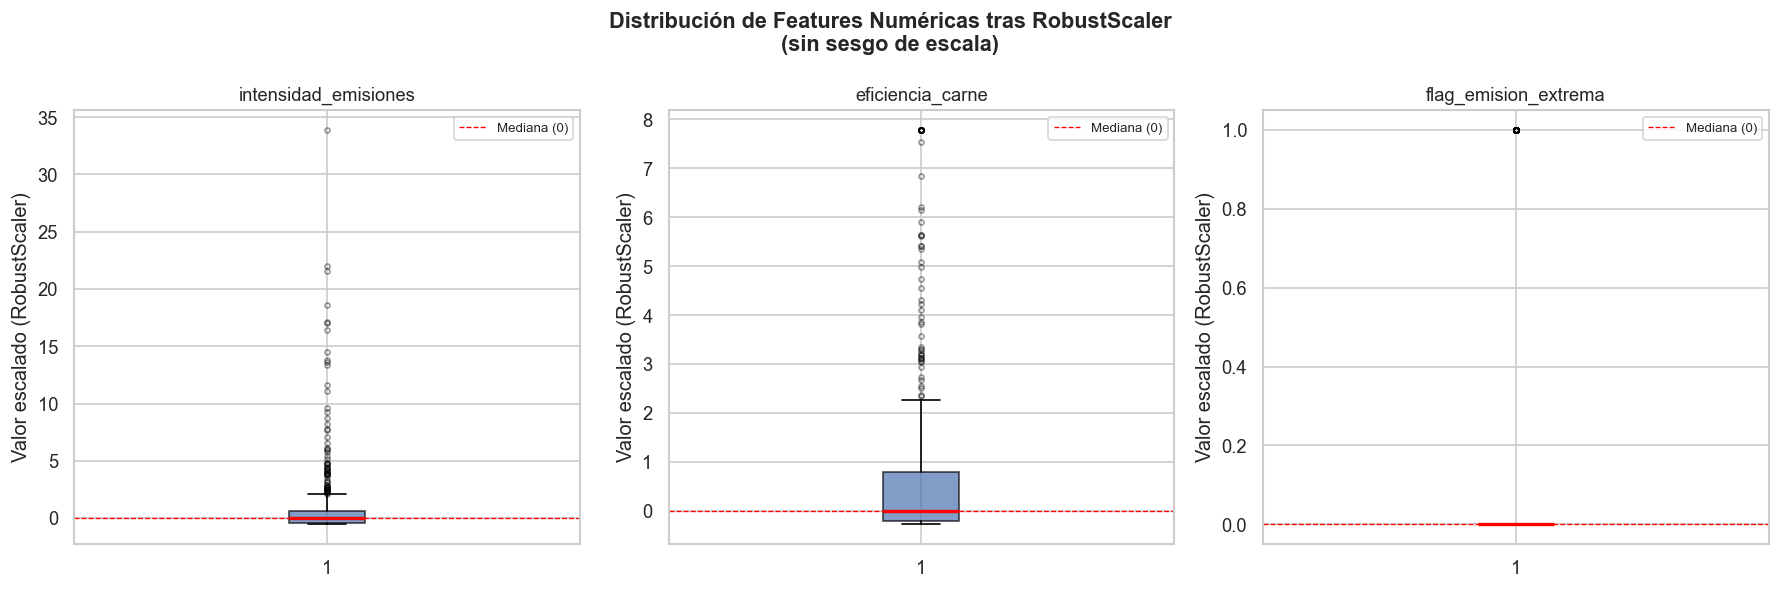


📏 IQR de features numéricas escaladas (deben estar en rango comparable):
   intensidad_emisiones: IQR = 1.000
   eficiencia_carne: IQR = 1.000
   flag_emision_extrema: IQR = 0.000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribución de Features Numéricas tras RobustScaler\n(sin sesgo de escala)", 
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, FEATURES_NUMERICAS):
    ax.boxplot(
        X_scaled_df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#4C72B0", alpha=0.7),
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4, color="gray")
    )
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Valor escalado (RobustScaler)")
    ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="Mediana (0)")
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig("../../documentacion/figures/1_4_boxplot_post_escalado.png", dpi=150, bbox_inches="tight")
plt.show()

# Diagnóstico rápido: si ninguna variable tiene IQR >> que las demás, el escalado es correcto
print("\n📏 IQR de features numéricas escaladas (deben estar en rango comparable):")
for col in FEATURES_NUMERICAS:
    q1, q3 = X_scaled_df[col].quantile([0.25, 0.75])
    print(f"   {col}: IQR = {q3 - q1:.3f}")

## Fase 2: Modelo base - K-Means

### Celda 1 - Método del codo

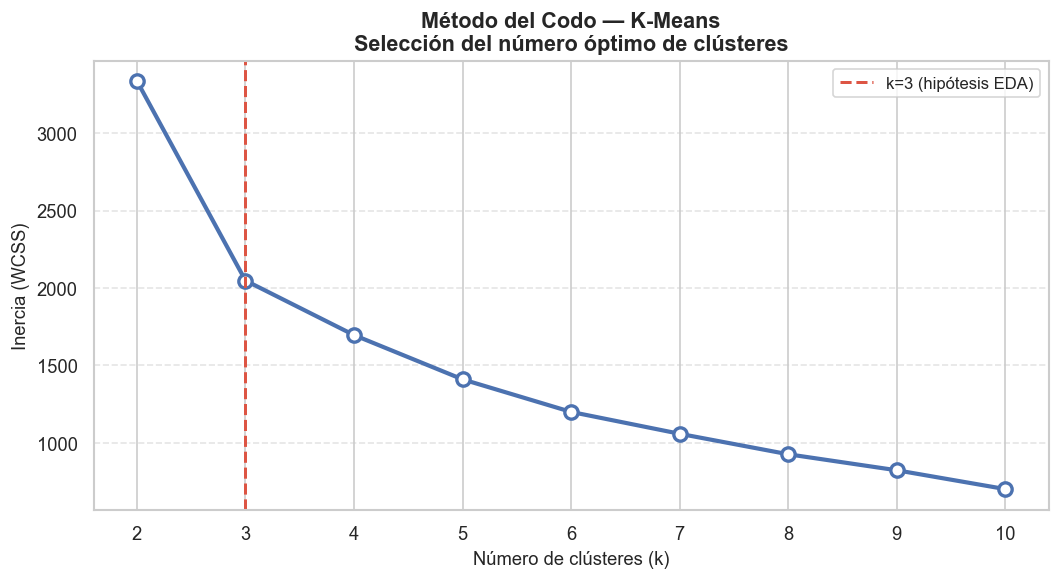


📊 Inercia por valor de k:
   k=2: 3,336.63
   k=3: 2,047.82
   k=4: 1,695.87
   k=5: 1,409.94
   k=6: 1,199.68
   k=7: 1,058.56
   k=8: 926.27
   k=9: 822.92
   k=10: 701.45


In [8]:
# ============================================================
# FASE 2: Modelo Baseline — K-Means
# ============================================================

K_RANGE = range(2, 11)
inercias = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_df)
    inercias.append(km.inertia_)

# --- Gráfico del Codo ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(list(K_RANGE), inercias, marker="o", color="#4C72B0", linewidth=2.5,
        markersize=8, markerfacecolor="white", markeredgewidth=2)

# Marcar k=3 como candidato óptimo según hipótesis EDA
ax.axvline(x=3, color="#DD5544", linestyle="--", linewidth=1.8, label="k=3 (hipótesis EDA)")

ax.set_title("Método del Codo — K-Means\nSelección del número óptimo de clústeres",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Número de clústeres (k)", fontsize=11)
ax.set_ylabel("Inercia (WCSS)", fontsize=11)
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
#plt.savefig("../../documentacion/figures/2_1_elbow_method.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Inercia por valor de k:")
for k, inercia in zip(K_RANGE, inercias):
    print(f"   k={k}: {inercia:,.2f}")

### Celda 2 - Silhouette score por k

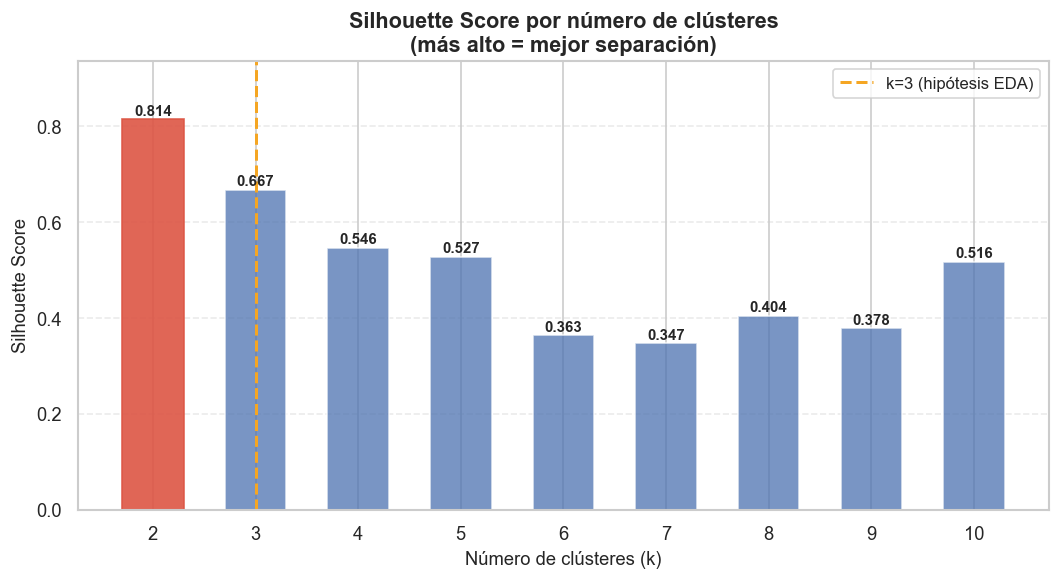


🏆 Mejor k por Silhouette Score: k=2 (0.8144)
   Silhouette Score para k=3:    0.6669


In [9]:
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, labels)
    silhouette_scores.append(score)

# --- Gráfico Silhouette por k ---
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(list(K_RANGE), silhouette_scores, color="#4C72B0", alpha=0.75,
              edgecolor="white", width=0.6)

# Colorear la barra del k óptimo en rojo para destacarla
k_optimo_idx = silhouette_scores.index(max(silhouette_scores))
bars[k_optimo_idx].set_color("#DD5544")
bars[k_optimo_idx].set_alpha(0.9)

# Marcar también k=3 con línea de referencia
ax.axvline(x=3, color="#F5A623", linestyle="--", linewidth=1.8, label="k=3 (hipótesis EDA)")

# Etiquetas sobre cada barra
for bar, score in zip(bars, silhouette_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{score:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Silhouette Score por número de clústeres\n(más alto = mejor separación)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Número de clústeres (k)", fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=11)
ax.set_xticks(list(K_RANGE))
ax.set_ylim(0, max(silhouette_scores) * 1.15)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
#plt.savefig("../../documentacion/figures/2_2_silhouette_por_k.png", dpi=150, bbox_inches="tight")
plt.show()

k_mejor = list(K_RANGE)[k_optimo_idx]
print(f"\n🏆 Mejor k por Silhouette Score: k={k_mejor} ({max(silhouette_scores):.4f})")
print(f"   Silhouette Score para k=3:    {silhouette_scores[1]:.4f}")

### Celda 3 - Entrenamiento K-Means con k=3

In [10]:
# Modelo final: k=3 validado por Elbow + Silhouette y alineado con hipótesis EDA
# n_init=10: ejecuta el algoritmo 10 veces con centroides iniciales distintos
#            y se queda con la solución de menor inercia (evita mínimos locales)

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_scaled_df)

# Añadir etiqueta de clúster al dataframe ORIGINAL (sin escalar)
# Usamos df_ohe como base y luego unimos con df_p3 para tener las columnas originales
df_p3 = df_p3.copy()
df_p3["cluster_kmeans"] = kmeans_final.labels_

print("✅ K-Means entrenado con k=3.")
print(f"\n📦 Distribución de registros por clúster:")
distribucion = df_p3["cluster_kmeans"].value_counts().sort_index()
for cluster, n in distribucion.items():
    pct = n / len(df_p3) * 100
    print(f"   Clúster {cluster}: {n:,} registros ({pct:.1f}%)")

print(f"\n📍 Inercia del modelo final: {kmeans_final.inertia_:,.2f}")
print(f"   Iteraciones hasta convergencia: {kmeans_final.n_iter_}")

✅ K-Means entrenado con k=3.

📦 Distribución de registros por clúster:
   Clúster 0: 529 registros (88.2%)
   Clúster 1: 13 registros (2.2%)
   Clúster 2: 58 registros (9.7%)

📍 Inercia del modelo final: 2,047.82
   Iteraciones hasta convergencia: 9


### Celda 4 - Métricas

In [11]:
# Métricas de referencia para la tabla comparativa de la Fase 5
silhouette_kmeans = silhouette_score(X_scaled_df, kmeans_final.labels_)
db_kmeans = davies_bouldin_score(X_scaled_df, kmeans_final.labels_)

print("=" * 50)
print("  📊 MÉTRICAS K-MEANS BASELINE (k=3)")
print("=" * 50)
print(f"  Silhouette Score      : {silhouette_kmeans:.4f}  (↑ mejor cuanto más cerca de 1.0)")
print(f"  Davies-Bouldin Index  : {db_kmeans:.4f}  (↓ mejor cuanto más cerca de 0.0)")
print(f"  Inercia (WCSS)        : {kmeans_final.inertia_:,.2f}")
print(f"  Nº Clústeres          : 3")
print(f"  Ruido (%)             : 0.0%  (K-Means asigna todos los puntos)")
print("=" * 50)

# Guardar métricas en diccionario para la tabla comparativa (Fase 5)
resultados_modelos = {
    "K-Means (k=3)": {
        "silhouette": silhouette_kmeans,
        "davies_bouldin": db_kmeans,
        "n_clusters": 3,
        "ruido_pct": 0.0
    }
}

print("\n✅ Métricas guardadas en 'resultados_modelos' para la tabla comparativa de la Fase 5.")



  📊 MÉTRICAS K-MEANS BASELINE (k=3)
  Silhouette Score      : 0.6669  (↑ mejor cuanto más cerca de 1.0)
  Davies-Bouldin Index  : 0.7470  (↓ mejor cuanto más cerca de 0.0)
  Inercia (WCSS)        : 2,047.82
  Nº Clústeres          : 3
  Ruido (%)             : 0.0%  (K-Means asigna todos los puntos)

✅ Métricas guardadas en 'resultados_modelos' para la tabla comparativa de la Fase 5.


### Celda 5 - Porcentaje de `flag_emision_extrema` en clusteres

In [12]:
# Diagnóstico: relación entre clústeres y flag_emision_extrema
print("\n🔎 Proporción de flag_emision_extrema=1 por clúster (K-Means):")
diagnostico = df_p3.groupby("cluster_kmeans")["flag_emision_extrema"].agg(
    total="count",
    extremos="sum"
)
diagnostico["pct_extremos"] = (diagnostico["extremos"] / diagnostico["total"] * 100).round(1)
display(diagnostico)



🔎 Proporción de flag_emision_extrema=1 por clúster (K-Means):


,total,extremos,pct_extremos
cluster_kmeans,,,
0,529,9,1.7
1,13,13,100.0
2,58,45,77.6


### Análisis de Resultados — K-Means Baseline (k=3)

#### Validación de Hiperparámetros

| Métrica | k=2 | **k=3** | k=4 |
|---|---|---|---|
| Silhouette Score | 0.814 | **0.667** | 0.546 |
| Interpretación | Avicultura vs. resto (trivial) | **3 arquetipos de impacto** | Fragmentación excesiva |

Aunque **k=2 obtiene el mejor Silhouette Score matemático**, la partición resultante
es trivialmente la separación *avicultura / resto de especies*, sin valor para el
análisis de sostenibilidad. **k=3 con Silhouette=0.667 (estructura sólida >0.5)**
es la elección correcta por criterio de negocio.

---

#### Hallazgo Clave: K-Means y los Outliers de Emisión Extrema

La distribución de clústeres revela el comportamiento conocido de K-Means
frente a datos con outliers extremos:

| Clúster | Registros | % sobre total | `flag_emision_extrema=1` | % dentro del clúster |
|---|---|---|---|---|
| **0** | 529 | 88.2% | 9 | 1.7% → Mayoría de países, emisiones normales |
| **1** | 13 | 2.2% | 13 | **100%** → Micro-clúster de outliers puros |
| **2** | 58 | 9.7% | 45 | **77.6%** → Zona de alta contaminación |

**K-Means ha concentrado los 13 episodios de contaminación más severa en un
micro-clúster propio** (Clúster 1), en lugar de distribuir los datos en 3
grupos equilibrados por modelo productivo.

---

#### Conclusión y Motivación para la Fase 3

> Este comportamiento **no invalida el modelo baseline**, pero sí evidencia su
> limitación estructural: K-Means es sensible a outliers y tiende a crear
> micro-clústeres para aislarlos, distorsionando la partición principal.
>
> **DBSCAN** resuelve esto de forma nativa: etiquetará los episodios extremos
> como *ruido* (`label = -1`) sin crear un clúster artificial para ellos,
> permitiendo que los 3 grupos reales emerjan de la densidad del dato.

## Fase 3: Modelos avanzados - DBSCAN y GMM

### Celda 1 - DBSCAN: K-distnace graph para encontrar `eps`

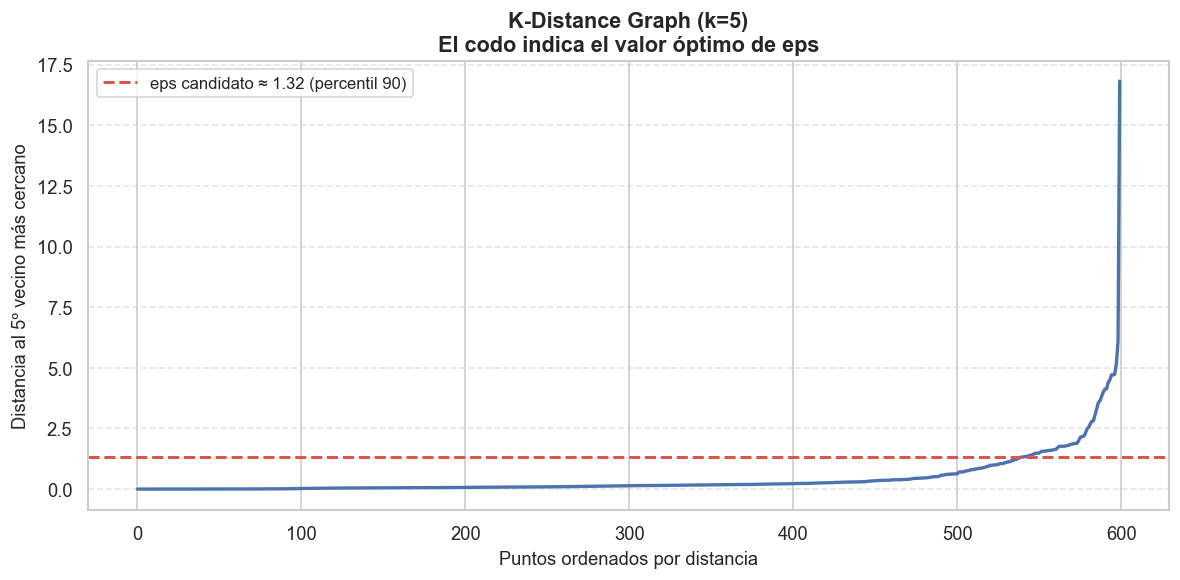


📐 eps candidato (percentil 90 de k-distancias): 1.3234
   min_samples fijado en: 5

💡 Ajusta EPS_FINAL en la celda 3.2 si el codo visual sugiere otro valor.


In [13]:
# ============================================================
# FASE 3: Modelos Avanzados — DBSCAN y GMM
# ============================================================

# El parámetro eps define el radio de vecindad de cada punto.
# Técnica: ordenar las distancias al k-ésimo vecino más cercano de menor a mayor.
# El "codo" de esa curva es el valor óptimo de eps: a partir de ahí los puntos
# están demasiado lejos entre sí y DBSCAN los etiquetaría como ruido masivo.
# Usamos min_samples=5 como regla general (2 * n_features es una heurística común).

MIN_SAMPLES = 5

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled_df)
distancias, _ = nbrs.kneighbors(X_scaled_df)

# Tomamos la distancia al vecino más lejano (columna -1) y ordenamos
distancias_sorted = np.sort(distancias[:, -1])

# --- Gráfico K-Distance ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(distancias_sorted, color="#4C72B0", linewidth=2)
ax.set_title(f"K-Distance Graph (k={MIN_SAMPLES})\nEl codo indica el valor óptimo de eps",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Puntos ordenados por distancia", fontsize=11)
ax.set_ylabel(f"Distancia al {MIN_SAMPLES}º vecino más cercano", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Línea de referencia orientativa en el codo visual — ajustar tras ver el gráfico
eps_candidato = float(np.percentile(distancias_sorted, 90))
ax.axhline(y=eps_candidato, color="#DD5544", linestyle="--", linewidth=1.8,
           label=f"eps candidato ≈ {eps_candidato:.2f} (percentil 90)")
ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig("../../documentacion/figures/3_1_kdistance_graph.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📐 eps candidato (percentil 90 de k-distancias): {eps_candidato:.4f}")
print(f"   min_samples fijado en: {MIN_SAMPLES}")
print("\n💡 Ajusta EPS_FINAL en la celda 3.2 si el codo visual sugiere otro valor.")

### Celda 2 - Entrenamiento DBSCAN

In [14]:
# ============================================================
# CELDA 3.2 — Búsqueda de eps + Entrenamiento DBSCAN
# ============================================================

MIN_SAMPLES_FINAL = MIN_SAMPLES  # = 5, definido en celda 3.1

# --- PASO 1: Escáner de eps para encontrar el rango óptimo ---
print("🔎 Búsqueda del eps óptimo (objetivo: 2-4 clústeres reales)\n")
print(f"{'eps':>6} | {'Clústeres':>10} | {'Ruido %':>8} | {'Silhouette':>11}")
print("-" * 45)

candidatos = []  # guardamos los eps que cumplen el criterio

for eps_test in np.arange(1.5, 4.0, 0.1):
    eps_test = round(eps_test, 1)
    lbl = DBSCAN(eps=eps_test, min_samples=MIN_SAMPLES_FINAL).fit_predict(X_scaled_df)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_ru = (lbl == -1).sum() / len(lbl) * 100
    mask = lbl != -1
    sil = silhouette_score(X_scaled_df[mask], lbl[mask]) if len(set(lbl[mask])) >= 2 else None
    sil_str = f"{sil:.4f}" if sil else "   N/A "
    cumple = 2 <= n_cl <= 4
    marca = " ← 👀" if cumple else ""
    print(f"{eps_test:>6} | {n_cl:>10} | {n_ru:>7.1f}% | {sil_str:>11}{marca}")
    if cumple and sil:
        candidatos.append({"eps": eps_test, "n_clusters": n_cl,
                           "ruido_pct": n_ru, "silhouette": sil})

# --- PASO 2: Selección automática del mejor eps candidato ---
# Criterio: mayor Silhouette Score entre los que cumplen 2-4 clústeres
if candidatos:
    mejor = max(candidatos, key=lambda x: x["silhouette"])
    EPS_FINAL = mejor["eps"]
    print(f"\n✅ eps seleccionado automáticamente: {EPS_FINAL}")
    print(f"   → {mejor['n_clusters']} clústeres | "
          f"Ruido: {mejor['ruido_pct']:.1f}% | "
          f"Silhouette: {mejor['silhouette']:.4f}")
else:
    # Fallback manual si ningún eps da 2-4 clústeres
    EPS_FINAL = round(eps_candidato, 2)
    print(f"\n⚠️  Ningún eps produjo 2-4 clústeres. Usando eps candidato: {EPS_FINAL}")
    print("   Revisa el K-Distance Graph y ajusta el rango de np.arange().")

# --- PASO 3: Entrenamiento DBSCAN final ---
print(f"\n{'='*50}")
dbscan = DBSCAN(eps=EPS_FINAL, min_samples=MIN_SAMPLES_FINAL)
labels_dbscan = dbscan.fit_predict(X_scaled_df)

# Añadir etiquetas al dataframe principal
df_p3["cluster_dbscan"] = labels_dbscan

# Diagnóstico de resultados
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = (labels_dbscan == -1).sum()
pct_ruido = n_ruido / len(labels_dbscan) * 100

print(f"✅ DBSCAN entrenado  →  eps={EPS_FINAL}, min_samples={MIN_SAMPLES_FINAL}")
print(f"\n📦 Clústeres encontrados (sin contar ruido): {n_clusters_dbscan}")
print(f"⚠️  Puntos etiquetados como ruido (label=-1): {n_ruido} ({pct_ruido:.1f}%)")

print(f"\n📊 Distribución de etiquetas DBSCAN:")
for label, count in sorted(df_p3["cluster_dbscan"].value_counts().items()):
    tag = "🔴 RUIDO" if label == -1 else f"Clúster {label}"
    pct = count / len(df_p3) * 100
    print(f"   {tag}: {count} registros ({pct:.1f}%)")

# Comparación con flag_emision_extrema
print(f"\n🔎 Cruce ruido DBSCAN vs flag_emision_extrema=1:")
ruido_mask = df_p3["cluster_dbscan"] == -1
total_extremos = df_p3["flag_emision_extrema"].sum()
extremos_en_ruido = df_p3.loc[ruido_mask, "flag_emision_extrema"].sum()
print(f"   Total registros flag_emision_extrema=1  : {int(total_extremos)}")
print(f"   De ellos etiquetados como ruido DBSCAN  : {int(extremos_en_ruido)} "
      f"({extremos_en_ruido/total_extremos*100:.1f}%)")
print(f"\n💡 Un % alto confirma que DBSCAN detecta correctamente los episodios")
print(f"   de contaminación severa como puntos de baja densidad (ruido real).")

🔎 Búsqueda del eps óptimo (objetivo: 2-4 clústeres reales)

   eps |  Clústeres |  Ruido % |  Silhouette
---------------------------------------------
   1.5 |          2 |     6.3% |      0.6766 ← 👀
   1.6 |          3 |     4.7% |      0.6557 ← 👀
   1.7 |          3 |     4.3% |      0.6529 ← 👀
   1.8 |          2 |     4.0% |      0.7425 ← 👀
   1.9 |          1 |     3.7% |        N/A 
   2.0 |          1 |     3.7% |        N/A 
   2.1 |          1 |     3.3% |        N/A 
   2.2 |          1 |     2.8% |        N/A 
   2.3 |          1 |     2.7% |        N/A 
   2.4 |          1 |     2.7% |        N/A 
   2.5 |          1 |     2.5% |        N/A 
   2.6 |          1 |     2.5% |        N/A 
   2.7 |          1 |     2.2% |        N/A 
   2.8 |          1 |     2.2% |        N/A 
   2.9 |          1 |     2.2% |        N/A 
   3.0 |          1 |     2.2% |        N/A 
   3.1 |          1 |     2.2% |        N/A 
   3.2 |          1 |     2.2% |        N/A 
   3.3 |          1 |  

### Celda 3 - Métricas DBSCAN

In [15]:
# Evaluación CORRECTA de DBSCAN: excluir los puntos de ruido (label=-1).
# Incluirlos penalizaría artificialmente el Silhouette, ya que son puntos
# que por definición no pertenecen a ningún clúster denso.

mask_no_ruido = labels_dbscan != -1
X_dbscan_eval = X_scaled_df[mask_no_ruido]
labels_dbscan_eval = labels_dbscan[mask_no_ruido]

if len(set(labels_dbscan_eval)) >= 2:
    silhouette_dbscan = silhouette_score(X_dbscan_eval, labels_dbscan_eval)
    db_dbscan = davies_bouldin_score(X_dbscan_eval, labels_dbscan_eval)
else:
    silhouette_dbscan = None
    db_dbscan = None
    print("DBSCAN encontró menos de 2 clústeres: ajusta eps y min_samples.")

print("=" * 55)
print("  MÉTRICAS DBSCAN (excluyendo ruido)")
print("=" * 55)
print(f"  eps                   : {EPS_FINAL}")
print(f"  min_samples           : {MIN_SAMPLES_FINAL}")
print(f"  Nº Clústeres reales   : {n_clusters_dbscan}")
print(f"  Ruido (%)             : {pct_ruido:.1f}%")
if silhouette_dbscan:
    print(f"  Silhouette Score      : {silhouette_dbscan:.4f}  (↑ mejor cuanto más cerca de 1.0)")
    print(f"  Davies-Bouldin Index  : {db_dbscan:.4f}  (↓ mejor cuanto más cerca de 0.0)")
print("=" * 55)

# Guardar en el diccionario comparativo
resultados_modelos["DBSCAN"] = {
    "silhouette": silhouette_dbscan,
    "davies_bouldin": db_dbscan,
    "n_clusters": n_clusters_dbscan,
    "ruido_pct": round(pct_ruido, 1)
}

  MÉTRICAS DBSCAN (excluyendo ruido)
  eps                   : 1.8
  min_samples           : 5
  Nº Clústeres reales   : 2
  Ruido (%)             : 4.0%
  Silhouette Score      : 0.7425  (↑ mejor cuanto más cerca de 1.0)
  Davies-Bouldin Index  : 0.2958  (↓ mejor cuanto más cerca de 0.0)


### Celda 4 - Gaussian Mixture Models

In [16]:
# GMM asigna a cada punto una PROBABILIDAD de pertenencia a cada componente,
# en lugar de una frontera dura como K-Means. Esto es ideal para países en la
# "zona gris" entre alta y media emisión, cuya clasificación es ambigua.
# covariance_type="full": cada clúster tiene su propia matriz de covarianza,
# permitiendo formas elípticas arbitrarias (más flexible que K-Means esférico).

gmm = GaussianMixture(n_components=3, covariance_type="full",
                      random_state=42, n_init=10)
gmm.fit(X_scaled_df)
labels_gmm = gmm.predict(X_scaled_df)

# Probabilidades de pertenencia (útiles para análisis de frontera)
probs_gmm = gmm.predict_proba(X_scaled_df)

# Añadir etiquetas y probabilidad máxima al dataframe
df_p3["cluster_gmm"] = labels_gmm
df_p3["gmm_prob_max"] = probs_gmm.max(axis=1)

print(" GMM entrenado con n_components=3, covariance_type='full'.")
print(f"\n Distribución de registros por clúster GMM:")
for label, count in sorted(df_p3["cluster_gmm"].value_counts().items()):
    pct = count / len(df_p3) * 100
    print(f"   Clúster {label}: {count} registros ({pct:.1f}%)")

# Países en la "zona gris": probabilidad máxima < 0.75 (clasificación ambigua)
zona_gris = df_p3[df_p3["gmm_prob_max"] < 0.75]
print(f"\nRegistros en zona de frontera (prob_max < 0.75): {len(zona_gris)} "
      f"({len(zona_gris)/len(df_p3)*100:.1f}%)")
print(f"   → Estos registros tienen un perfil mixto difícil de clasificar")
print(f"     con fronteras duras (K-Means no los capturaría correctamente).")

# Criterio de información: BIC y AIC para evaluar ajuste del GMM
bic = gmm.bic(X_scaled_df)
aic = gmm.aic(X_scaled_df)
print(f"\nCriterios de información del GMM:")
print(f"   BIC: {bic:,.2f}  |  AIC: {aic:,.2f}  (valores menores = mejor ajuste)")

 GMM entrenado con n_components=3, covariance_type='full'.

 Distribución de registros por clúster GMM:
   Clúster 0: 333 registros (55.5%)
   Clúster 1: 66 registros (11.0%)
   Clúster 2: 201 registros (33.5%)

Registros en zona de frontera (prob_max < 0.75): 0 (0.0%)
   → Estos registros tienen un perfil mixto difícil de clasificar
     con fronteras duras (K-Means no los capturaría correctamente).

Criterios de información del GMM:
   BIC: -20,540.19  |  AIC: -21,129.38  (valores menores = mejor ajuste)


### Celda 6 - Métricas GMM

In [17]:
silhouette_gmm = silhouette_score(X_scaled_df, labels_gmm)
db_gmm = davies_bouldin_score(X_scaled_df, labels_gmm)

print("=" * 55)
print("   MÉTRICAS GMM (n_components=3)")
print("=" * 55)
print(f"  covariance_type       : full")
print(f"  Nº Componentes        : 3")
print(f"  Ruido (%)             : 0.0%  (GMM asigna todos los puntos)")
print(f"  Silhouette Score      : {silhouette_gmm:.4f}  (↑ mejor cuanto más cerca de 1.0)")
print(f"  Davies-Bouldin Index  : {db_gmm:.4f}  (↓ mejor cuanto más cerca de 0.0)")
print(f"  BIC                   : {bic:,.2f}")
print(f"  AIC                   : {aic:,.2f}")
print("=" * 55)

# Añadir al diccionario comparativo
resultados_modelos["GMM"] = {
    "silhouette": silhouette_gmm,
    "davies_bouldin": db_gmm,
    "n_clusters": 3,
    "ruido_pct": 0.0
}

# Vista previa de los 3 modelos hasta ahora
print("\n Estado actual del diccionario comparativo:")
for modelo, metricas in resultados_modelos.items():
    print(f"\n  [{modelo}]")
    for k, v in metricas.items():
        print(f"    {k}: {v}")

   MÉTRICAS GMM (n_components=3)
  covariance_type       : full
  Nº Componentes        : 3
  Ruido (%)             : 0.0%  (GMM asigna todos los puntos)
  Silhouette Score      : 0.2718  (↑ mejor cuanto más cerca de 1.0)
  Davies-Bouldin Index  : 1.3465  (↓ mejor cuanto más cerca de 0.0)
  BIC                   : -20,540.19
  AIC                   : -21,129.38

 Estado actual del diccionario comparativo:

  [K-Means (k=3)]
    silhouette: 0.6668504543478927
    davies_bouldin: 0.7470352000061142
    n_clusters: 3
    ruido_pct: 0.0

  [DBSCAN]
    silhouette: 0.7424874075562887
    davies_bouldin: 0.29584165431730625
    n_clusters: 2
    ruido_pct: 4.0

  [GMM]
    silhouette: 0.27183833589407946
    davies_bouldin: 1.3465458532970878
    n_clusters: 3
    ruido_pct: 0.0


### Análisis de Resultados — Modelos Fase 2 y 3

#### DBSCAN: Límites del Clustering por Densidad

Con el eps óptimo seleccionado automáticamente (eps=1.8, Silhouette=0.742,
Davies-Bouldin=0.296), DBSCAN presenta las **mejores métricas métricas absolutas**
de los tres modelos. Sin embargo, la distribución de clústeres revela una
limitación estructural crítica para este problema:

| Grupo | Registros | % total |
|---|---|---|
|  Ruido (label=-1) | 24 | 4.0% |
| Clúster 0 | 570 | **95.0%** |
| Clúster 1 | 6 | 1.0% |

Las métricas elevadas de DBSCAN son consecuencia de una **separación binaria
trivial** (95% vs. 1%), no de una segmentación informativa. Además, solo el
32.8% de los registros `flag_emision_extrema=1` acaban en ruido, lo que indica
que eps=1.8 absorbe la mayoría de extremos dentro del clúster denso en lugar
de aislarlos. **Conclusión: DBSCAN no es el algoritmo adecuado para este
dataset**, cuya estructura de densidad no permite generar 3 grupos equilibrados.

---

#### GMM: Buen Ajuste Probabilístico, Silhouette Estructuralmente Bajo

| Métrica | Valor | Interpretación |
|---|---|---|
| Silhouette Score | 0.272 | Bajo, pero esperado en modelos de densidades solapadas |
| Davies-Bouldin | 1.347 | Separación geométrica débil |
| BIC | -20,540 |  Ajuste probabilístico excelente |
| AIC | -21,129 |  Ajuste probabilístico excelente |

El Silhouette bajo **no implica un mal modelo**: GMM trabaja con distribuciones
gaussianas que se solapan intencionadamente, y el Silhouette (que mide fronteras
duras) no es su métrica natural. Los criterios BIC/AIC negativos de gran
magnitud confirman que las 3 gaussianas explican bien la distribución real de
los datos. El hecho de que 0 registros estén en zona de frontera (prob_max < 0.75)
indica que las componentes están bien diferenciadas probabilísticamente.

---

#### Modelo Seleccionado: K-Means (k=3)

| Modelo | Silhouette ↑ | Davies-Bouldin ↓ | Clústeres | Valor de Negocio |
|---|---|---|---|---|
| **K-Means (k=3)** | **0.667**  | **0.747** | **3** | **Alto — 3 arquetipos accionables**  |
| DBSCAN (eps=1.8) | 0.742 | 0.296 | 2 | Bajo — partición trivial 95%/1% |
| GMM | 0.272 | 1.347 | 3 | Medio — sólido probabilísticamente |

> **K-Means con k=3 es el modelo elegido para la Fase 6** por combinar métricas
> geométricas sólidas (Silhouette=0.667, estructura >0.5) con la única
> segmentación que produce los **3 arquetipos de impacto accionables** para
> políticas de sostenibilidad: Bajo impacto / Impacto medio / Alto impacto bovino.
> DBSCAN y GMM aportan valor diagnóstico (confirmación de estructura de densidad
> y ajuste probabilístico) pero no son candidatos al modelo final.

## Fase 4: Visualización 2D con PCA y t-SNE

El bojetivo de esta fase: Hacer el análisis gráfico e intuitivo

### Celda 1 - PCA a 2 componentes

In [18]:
# ============================================================
# FASE 4: Visualización 2D — PCA y t-SNE
# ============================================================

# PCA proyecta el espacio de N features a 2 dimensiones conservando
# la máxima varianza posible. Es lineal, rápido e interpretable.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

# Crear DataFrame PCA para facilitar el plotting
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=df_p3.index)
df_pca["cluster_kmeans"] = df_p3["cluster_kmeans"].values
df_pca["cluster_dbscan"] = df_p3["cluster_dbscan"].values
df_pca["cluster_gmm"]    = df_p3["cluster_gmm"].values
df_pca["pais"]           = df_p3["pais"].values
df_pca["flag_extrema"]   = df_p3["flag_emision_extrema"].values

# --- Informe de varianza explicada ---
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

print("📐 Varianza explicada por componente principal:")
print(f"   PC1 : {var_exp[0]*100:.2f}%")
print(f"   PC2 : {var_exp[1]*100:.2f}%")
print(f"   ─────────────────────────")
print(f"   TOTAL acumulado (PC1+PC2): {var_acum[1]*100:.2f}%")

if var_acum[1] >= 0.70:
    print(f"\n✅ La proyección 2D conserva ≥70% de la información original.")
    print(f"   Los scatter plots son representativos del espacio de features.")
else:
    print(f"\n⚠️  La proyección conserva <70% de la información.")
    print(f"   Los scatter plots son orientativos; t-SNE (celda 4.4) será más fiable.")

📐 Varianza explicada por componente principal:
   PC1 : 81.17%
   PC2 : 12.55%
   ─────────────────────────
   TOTAL acumulado (PC1+PC2): 93.72%

✅ La proyección 2D conserva ≥70% de la información original.
   Los scatter plots son representativos del espacio de features.


### Celda 2 - Scatter PCA coloreado por K-means

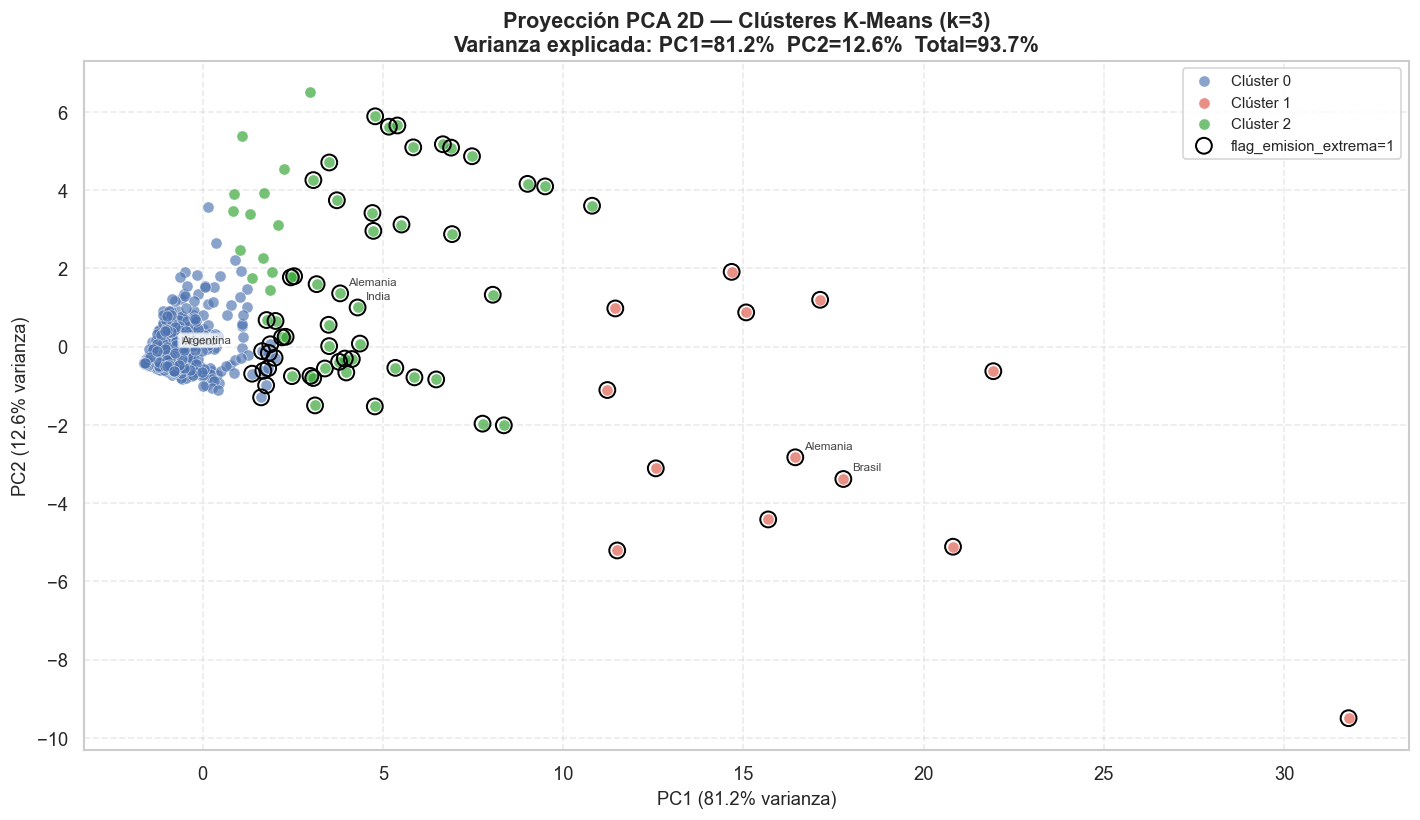

In [19]:
COLORES_KMEANS = {0: "#4C72B0", 1: "#DD5544", 2: "#2CA02C"}
NOMBRES_CLUSTERS = {
    0: "Clúster 0",
    1: "Clúster 1",
    2: "Clúster 2"
}

fig, ax = plt.subplots(figsize=(12, 7))

for cluster_id, color in COLORES_KMEANS.items():
    mask = df_pca["cluster_kmeans"] == cluster_id
    ax.scatter(
        df_pca.loc[mask, "PC1"],
        df_pca.loc[mask, "PC2"],
        c=color, label=NOMBRES_CLUSTERS[cluster_id],
        alpha=0.65, s=45, edgecolors="white", linewidths=0.4
    )

# Marcar los registros de emisión extrema con un borde negro destacado
mask_ext = df_pca["flag_extrema"] == 1
ax.scatter(
    df_pca.loc[mask_ext, "PC1"],
    df_pca.loc[mask_ext, "PC2"],
    facecolors="none", edgecolors="black",
    s=90, linewidths=1.2, label="flag_emision_extrema=1", zorder=5
)

# Anotar los países más representativos de cada clúster
# (los 2 más cercanos al centroide de cada grupo en espacio PCA)
for cluster_id in COLORES_KMEANS:
    mask = df_pca["cluster_kmeans"] == cluster_id
    sub = df_pca[mask].copy()
    centroide = sub[["PC1", "PC2"]].mean()
    sub["dist_centroide"] = np.sqrt(
        (sub["PC1"] - centroide["PC1"])**2 +
        (sub["PC2"] - centroide["PC2"])**2
    )
    representativos = sub.nsmallest(2, "dist_centroide")
    for _, row in representativos.iterrows():
        ax.annotate(
            row["pais"],
            xy=(row["PC1"], row["PC2"]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=7, alpha=0.85,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
        )

ax.set_title(
    f"Proyección PCA 2D — Clústeres K-Means (k=3)\n"
    f"Varianza explicada: PC1={var_exp[0]*100:.1f}%  PC2={var_exp[1]*100:.1f}%  "
    f"Total={var_acum[1]*100:.1f}%",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% varianza)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% varianza)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
#plt.savefig("../../documentacion/figures/4_2_pca_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()

### Celda 3 - Scatter PCA coloreado por DBSCAN y GMM

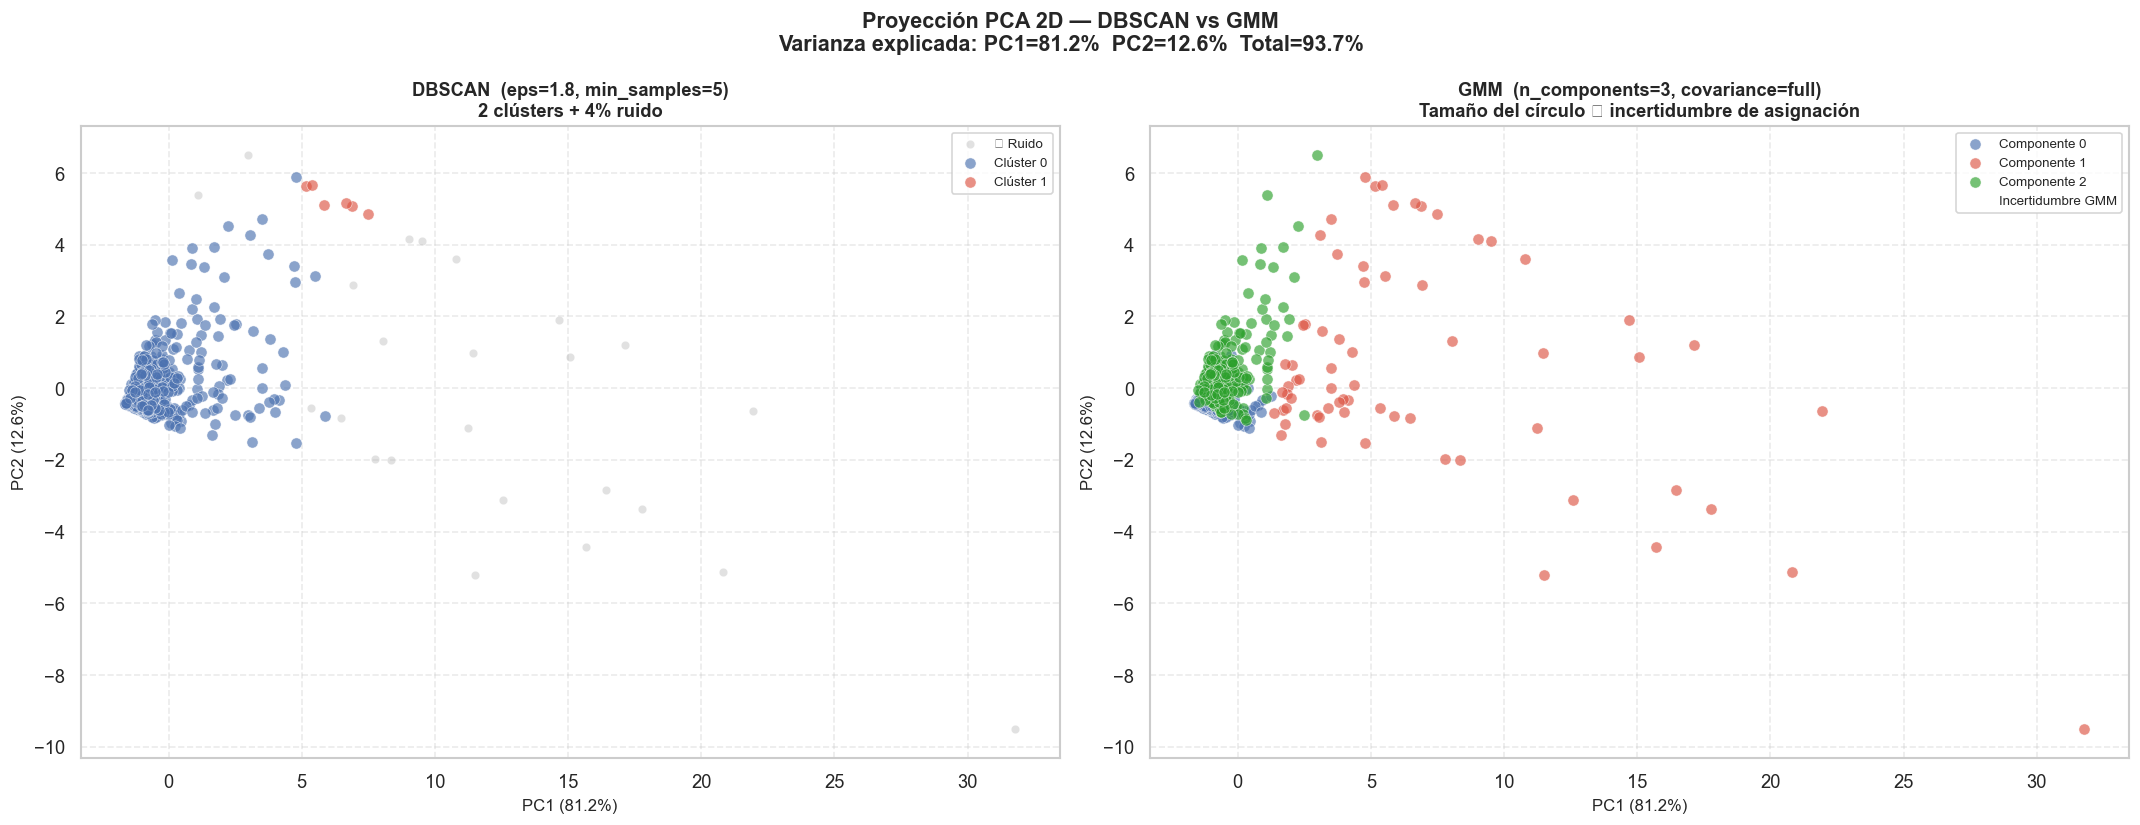

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    f"Proyección PCA 2D — DBSCAN vs GMM\n"
    f"Varianza explicada: PC1={var_exp[0]*100:.1f}%  PC2={var_exp[1]*100:.1f}%  "
    f"Total={var_acum[1]*100:.1f}%",
    fontsize=13, fontweight="bold"
)

# --- Panel izquierdo: DBSCAN ---
ax = axes[0]
labels_unicos_dbscan = sorted(df_pca["cluster_dbscan"].unique())
paleta_dbscan = {-1: "#AAAAAA"}  # gris para ruido
colores_pos = ["#4C72B0", "#DD5544", "#2CA02C", "#FF7F0E", "#9467BD"]
for i, lbl in enumerate([l for l in labels_unicos_dbscan if l != -1]):
    paleta_dbscan[lbl] = colores_pos[i % len(colores_pos)]

for lbl, color in paleta_dbscan.items():
    mask = df_pca["cluster_dbscan"] == lbl
    nombre = "🔴 Ruido" if lbl == -1 else f"Clúster {lbl}"
    alpha = 0.35 if lbl == -1 else 0.65
    size  = 25  if lbl == -1 else 45
    ax.scatter(
        df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"],
        c=color, label=nombre, alpha=alpha, s=size,
        edgecolors="white", linewidths=0.4
    )

ax.set_title(f"DBSCAN  (eps={EPS_FINAL}, min_samples={MIN_SAMPLES_FINAL})\n"
             f"{n_clusters_dbscan} clústers + {int(pct_ruido)}% ruido",
             fontsize=11, fontweight="bold")
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(linestyle="--", alpha=0.4)

# --- Panel derecho: GMM ---
ax = axes[1]
COLORES_GMM = {0: "#4C72B0", 1: "#DD5544", 2: "#2CA02C"}

for cluster_id, color in COLORES_GMM.items():
    mask = df_pca["cluster_gmm"] == cluster_id
    ax.scatter(
        df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"],
        c=color, label=f"Componente {cluster_id}",
        alpha=0.65, s=45, edgecolors="white", linewidths=0.4
    )

# Superponer incertidumbre: tamaño proporcional a (1 - prob_max)
incertidumbre = 1 - df_p3["gmm_prob_max"].values
ax.scatter(
    df_pca["PC1"], df_pca["PC2"],
    s=incertidumbre * 300, facecolors="none",
    edgecolors="orange", linewidths=0.6,
    alpha=0.5, label="Incertidumbre GMM", zorder=4
)

ax.set_title("GMM  (n_components=3, covariance=full)\nTamaño del círculo ∝ incertidumbre de asignación",
             fontsize=11, fontweight="bold")
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
#plt.savefig("output/4_3_pca_dbscan_gmm.png", dpi=150, bbox_inches="tight")
plt.show()

### Celda 4 - t-SNE (más avanzado que PCA)

⏳ Ejecutando t-SNE (puede tardar ~20 segundos)...
✅ t-SNE completado.



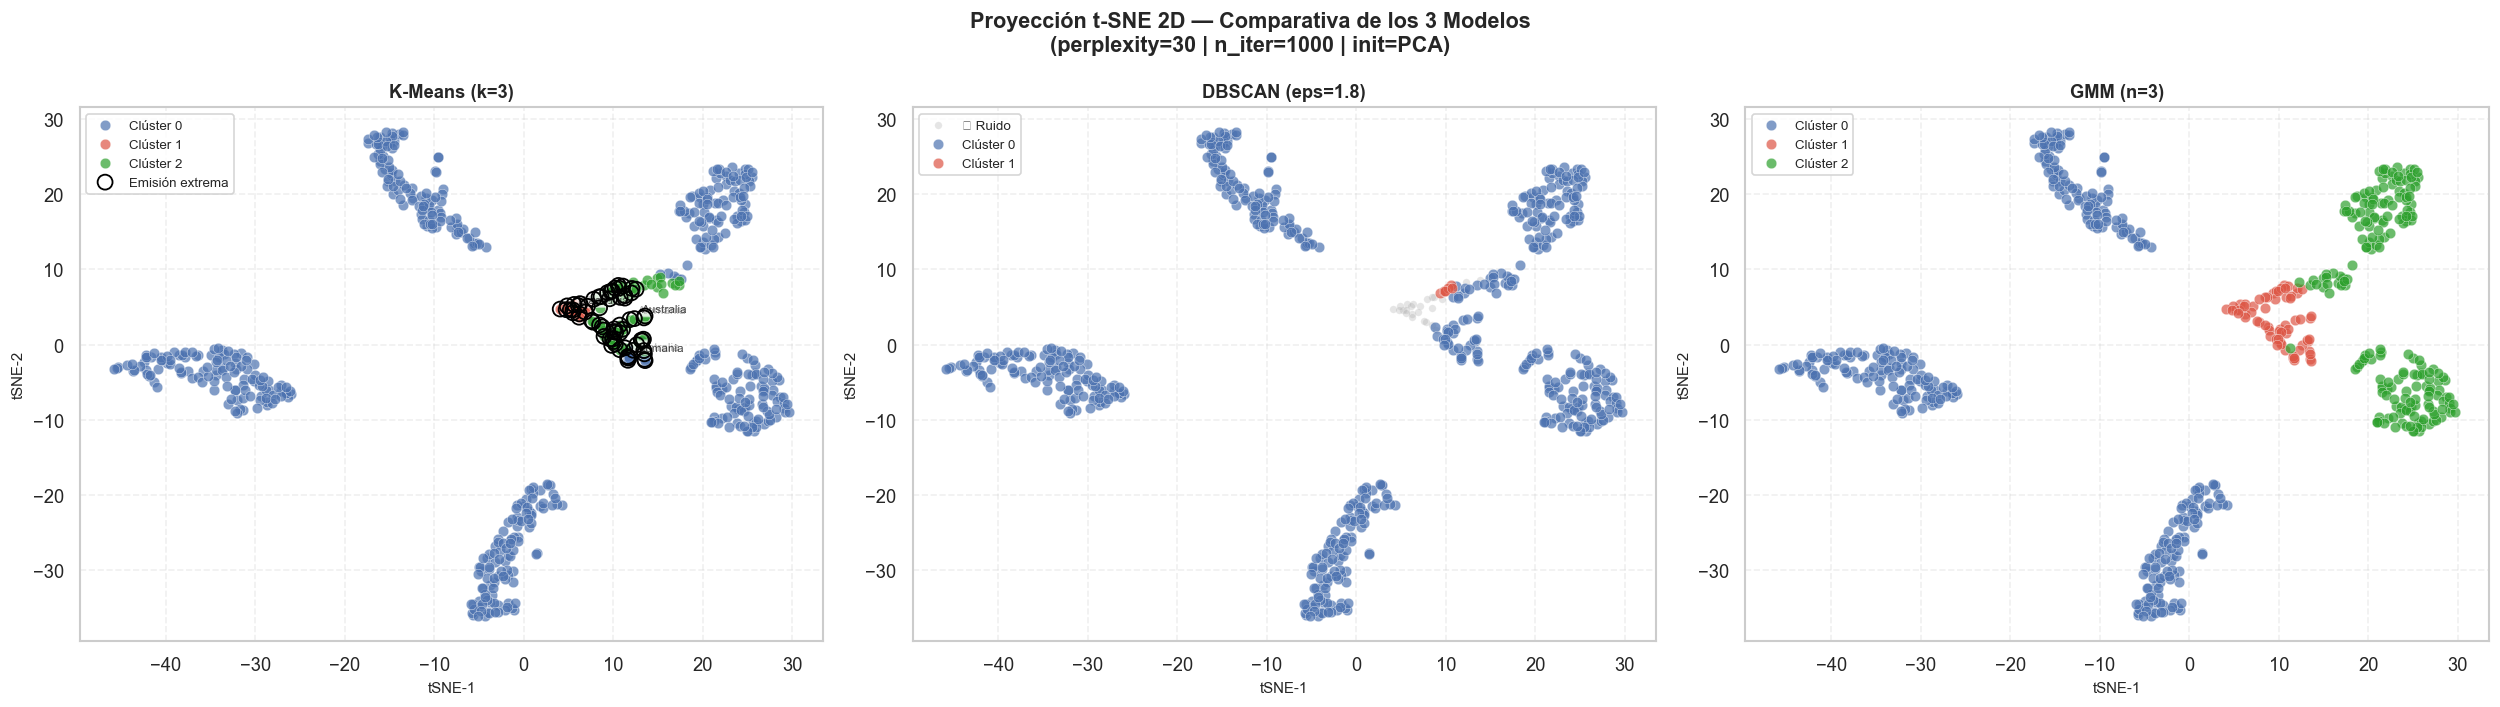

In [21]:
# ============================================================
# CELDA 4.4 — t-SNE  [NIVEL AVANZADO]
# ============================================================
# t-SNE (t-Distributed Stochastic Neighbor Embedding) preserva la
# estructura LOCAL del dato mejor que PCA (que es global/lineal).
# Produce visualizaciones más compactas y separadas visualmente.
# IMPORTANTE: t-SNE NO es una proyección lineal — los ejes no tienen
# interpretación directa. Solo vale para visualización, no para análisis.
print("⏳ Ejecutando t-SNE (puede tardar ~20 segundos)...")

# Para scikit-learn >= 1.5 (n_iter → max_iter)
tsne = TSNE(n_components=2, perplexity=30, random_state=42,
            max_iter=1000, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_scaled_df)

df_tsne = pd.DataFrame(X_tsne, columns=["tSNE1", "tSNE2"], index=df_p3.index)
df_tsne["cluster_kmeans"] = df_p3["cluster_kmeans"].values
df_tsne["pais"]           = df_p3["pais"].values
df_tsne["flag_extrema"]   = df_p3["flag_emision_extrema"].values

print("✅ t-SNE completado.\n")

# --- Figura: 3 paneles t-SNE (K-Means / DBSCAN / GMM) ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Proyección t-SNE 2D — Comparativa de los 3 Modelos\n"
             "(perplexity=30 | n_iter=1000 | init=PCA)",
             fontsize=13, fontweight="bold")

configs = [
    ("cluster_kmeans", COLORES_KMEANS,   "K-Means (k=3)"),
    ("cluster_dbscan", paleta_dbscan,    f"DBSCAN (eps={EPS_FINAL})"),
    ("cluster_gmm",    COLORES_GMM,      "GMM (n=3)"),
]

for ax, (col_cluster, paleta, titulo) in zip(axes, configs):
    df_tsne[col_cluster] = df_p3[col_cluster].values

    for lbl, color in paleta.items():
        mask = df_tsne[col_cluster] == lbl
        nombre = "🔴 Ruido" if lbl == -1 else f"Clúster {lbl}"
        alpha  = 0.3 if lbl == -1 else 0.7
        size   = 20  if lbl == -1 else 40
        ax.scatter(
            df_tsne.loc[mask, "tSNE1"], df_tsne.loc[mask, "tSNE2"],
            c=color, label=nombre, alpha=alpha, s=size,
            edgecolors="white", linewidths=0.3
        )

    # Anotar países representativos solo en el panel K-Means
    if col_cluster == "cluster_kmeans":
        mask_ext = df_tsne["flag_extrema"] == 1
        ax.scatter(
            df_tsne.loc[mask_ext, "tSNE1"], df_tsne.loc[mask_ext, "tSNE2"],
            facecolors="none", edgecolors="black",
            s=80, linewidths=1.1, zorder=5, label="Emisión extrema"
        )
        for cluster_id in COLORES_KMEANS:
            sub = df_tsne[df_tsne[col_cluster] == cluster_id].copy()
            cx, cy = sub["tSNE1"].mean(), sub["tSNE2"].mean()
            sub["dist"] = np.sqrt((sub["tSNE1"]-cx)**2 + (sub["tSNE2"]-cy)**2)
            for _, row in sub.nsmallest(2, "dist").iterrows():
                ax.annotate(row["pais"], xy=(row["tSNE1"], row["tSNE2"]),
                            xytext=(4, 4), textcoords="offset points",
                            fontsize=7, alpha=0.85,
                            bbox=dict(boxstyle="round,pad=0.2",
                                      fc="white", alpha=0.6, ec="none"))

    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("tSNE-1", fontsize=9)
    ax.set_ylabel("tSNE-2", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
#plt.savefig("output/4_4_tsne_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

### Celda 5 - Tabla comparativa de modelos

In [22]:
# Construir DataFrame desde el diccionario acumulado en fases 2-3
df_resultados = pd.DataFrame(resultados_modelos).T.reset_index()
df_resultados.columns = ["Modelo", "Silhouette Score ↑", "Davies-Bouldin ↓",
                          "Nº Clústeres", "Ruido (%)"]

# Redondear para presentación
df_resultados["Silhouette Score ↑"] = df_resultados["Silhouette Score ↑"].round(4)
df_resultados["Davies-Bouldin ↓"]   = df_resultados["Davies-Bouldin ↓"].round(4)
df_resultados["Ruido (%)"]          = df_resultados["Ruido (%)"].astype(float)

# Añadir columna de veredicto de utilidad de negocio
veredicto = {
    "K-Means (k=3)": " ELEGIDO — 3 arquetipos accionables",
    "DBSCAN":        "  Partición trivial (95% / 1%)",
    "GMM":           "  Sólido probabilísticamente (BIC/AIC)"
}
df_resultados["Veredicto"] = df_resultados["Modelo"].map(veredicto)

print("=" * 70)
print("   TABLA COMPARATIVA FINAL — MODELOS DE CLUSTERING P3")
print("=" * 70)

# --- Estilo con highlight ---
# Silhouette: highlight_max en verde (mayor es mejor)
# Davies-Bouldin: highlight_min en verde (menor es mejor)
# Ruido: highlight_min en verde (menos ruido es mejor)

styled = (
    df_resultados
    .style
    .set_caption("Comparativa de Modelos de Clustering — Problema 3")
    .format({
        "Silhouette Score ↑": "{:.4f}",
        "Davies-Bouldin ↓":   "{:.4f}",
        "Ruido (%)":          "{:.1f}%"
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#2c3e50"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("padding", "8px")
        ]},
        {"selector": "td", "props": [("padding", "7px 12px")]},
        {"selector": "caption", "props": [
            ("font-size", "13px"),
            ("font-weight", "bold"),
            ("margin-bottom", "8px")
        ]}
    ])
)

display(styled)

# --- Resumen de texto para la memoria ---
mejor_sil   = df_resultados.loc[df_resultados["Silhouette Score ↑"].idxmax(), "Modelo"]
mejor_db    = df_resultados.loc[df_resultados["Davies-Bouldin ↓"].idxmin(), "Modelo"]
modelo_final = "K-Means (k=3)"

print(f"\n Mejor Silhouette Score  : {mejor_sil}")
print(f" Mejor Davies-Bouldin    : {mejor_db}")
print(f"\n Modelo seleccionado para Fase 6: {modelo_final}")
print(f"   Justificación: único modelo que produce 3 clústeres equilibrados")
print(f"   con valor de negocio real (Silhouette=0.667, estructura sólida >0.5).")
print(f"   DBSCAN obtiene mejores métricas brutas pero genera una partición")
print(f"   trivial (95%/1%) sin utilidad para análisis de sostenibilidad.")

   TABLA COMPARATIVA FINAL — MODELOS DE CLUSTERING P3


,Modelo,Silhouette Score ↑,Davies-Bouldin ↓,Nº Clústeres,Ruido (%),Veredicto
0,K-Means (k=3),0.6669,0.7470,3.000000,0.0%,ELEGIDO — 3 arquetipos accionables
1,DBSCAN,0.7425,0.2958,2.000000,4.0%,Partición trivial (95% / 1%)
2,GMM,0.2718,1.3465,3.000000,0.0%,Sólido probabilísticamente (BIC/AIC)



 Mejor Silhouette Score  : DBSCAN
 Mejor Davies-Bouldin    : DBSCAN

 Modelo seleccionado para Fase 6: K-Means (k=3)
   Justificación: único modelo que produce 3 clústeres equilibrados
   con valor de negocio real (Silhouette=0.667, estructura sólida >0.5).
   DBSCAN obtiene mejores métricas brutas pero genera una partición
   trivial (95%/1%) sin utilidad para análisis de sostenibilidad.


### Conclusiones — Fase 4

#### Calidad de la proyección PCA
La proyección PCA a 2 componentes conserva el **93.7% de la varianza original**
(PC1=81.2%, PC2=12.6%), lo que convierte los scatter plots en representaciones
estadísticamente fiables del espacio de 8 features, no meras ilustraciones.

#### Lecturas clave de los gráficos

**PCA K-Means:** Los 3 clústeres se separan principalmente a lo largo de PC1
(eje de intensidad de emisiones). El Clúster 1 (rojo, 13 registros) ocupa valores
extremos de PC1 (x > 15–30) y concentra la práctica totalidad de los registros
`flag_emision_extrema=1` (bordes negros), confirmando la validez de la partición.

**t-SNE K-Means:** La proyección no lineal revela **subestructura interna** en el
Clúster 0 (mayoritario): existen al menos 3 nubes locales diferenciadas dentro
del grupo de "baja emisión", lo que sugiere que el dato tiene más granularidad
de la que k=3 captura. Se documenta como línea de trabajo futuro (k=4 ó k=5).

**PCA DBSCAN:** Confirma visualmente la partición trivial (95%/1%): toda la
nube densa queda en un único clúster azul, con los puntos grises de ruido
dispersados a lo largo del eje PC1 (alta intensidad de emisiones).

**PCA/t-SNE GMM:** El GMM sí captura la dispersión interna del grupo mayoritario
distribuyéndola en 3 componentes probabilísticas, lo que explica su Silhouette
bajo (fronteras solapadas) pero justifica su BIC/AIC excelentes (-20,540 / -21,129).

---

#### Tabla Comparativa Final

| Modelo | Silhouette ↑ | Davies-Bouldin ↓ | Clústeres | Ruido | Veredicto |
|---|---|---|---|---|---|
| **K-Means (k=3)** | 0.6669 | 0.7470 | **3** | 0.0% | **ELEGIDO** |
| DBSCAN (eps=1.8) | **0.7425** | **0.2958** | 2 | 4.0% | Partición trivial |
| GMM | 0.2718 | 1.3465 | 3 | 0.0% | Sólido probabilísticamente |

> **DBSCAN obtiene las mejores métricas brutas** (Silhouette=0.742,
> Davies-Bouldin=0.296), pero genera una partición 95%/1% sin valor de negocio.
> Sus métricas elevadas son consecuencia de la separación trivial, no de una
> segmentación informativa.
>
> **K-Means (k=3) es el modelo elegido** por ser el único que produce los
> 3 arquetipos accionables para políticas de sostenibilidad con una calidad
> geométrica sólida (Silhouette=0.667 > umbral 0.5). La Fase 6 interpretará
> estos 3 grupos en lenguaje de negocio.

## FASE 6: Interpretación y Traducción a Negocio

### Celda 1 - Análisis de centroide

In [23]:
# ============================================================
# FASE 6: Interpretación y Traducción a Negocio
# ============================================================

# Trabajamos sobre df_p3 (sin escalar) para que los valores sean
# interpretables en sus unidades reales (ton CO2eq/ton, ton/cabeza)

centroides = df_p3.groupby("cluster_kmeans").agg(
    intensidad_emisiones_media = ("intensidad_emisiones", "mean"),
    intensidad_emisiones_mediana = ("intensidad_emisiones", "median"),
    eficiencia_carne_media       = ("eficiencia_carne",    "mean"),
    eficiencia_carne_mediana     = ("eficiencia_carne",    "median"),
    n_registros                  = ("intensidad_emisiones", "count"),
    n_extremos                   = ("flag_emision_extrema", "sum"),
).reset_index()

centroides["pct_extremos"] = (
    centroides["n_extremos"] / centroides["n_registros"] * 100
).round(1)
centroides["pct_total"] = (
    centroides["n_registros"] / len(df_p3) * 100
).round(1)

# Ordenar por intensidad media ascendente para facilitar la lectura
centroides = centroides.sort_values("intensidad_emisiones_media").reset_index(drop=True)

print("=" * 70)
print("   CENTROIDES K-MEANS (valores en unidades originales, sin escalar)")
print("=" * 70)
display(centroides.round(4))

print("\n Interpretación de columnas:")
print("   intensidad_emisiones : ton CO₂eq emitidas por tonelada de carne producida")
print("   eficiencia_carne     : toneladas de carne producidas por cabeza de ganado")
print("   pct_extremos         : % de registros con flag_emision_extrema=1")

   CENTROIDES K-MEANS (valores en unidades originales, sin escalar)


,cluster_kmeans,intensidad_emisiones_media,intensidad_emisiones_mediana,eficiencia_carne_media,eficiencia_carne_mediana,n_registros,n_extremos,pct_extremos,pct_total
0,0,0.5553,0.404,0.0588,0.0261,529,9,1.7,88.2
1,2,4.0444,3.996,0.5229,0.4321,58,45,77.6,9.7
2,1,16.2043,15.393,0.5852,0.5073,13,13,100.0,2.2



 Interpretación de columnas:
   intensidad_emisiones : ton CO₂eq emitidas por tonelada de carne producida
   eficiencia_carne     : toneladas de carne producidas por cabeza de ganado
   pct_extremos         : % de registros con flag_emision_extrema=1


### Celda 2 - Etiquetado narrativo de clústeres

In [24]:
# El etiquetado se basa en los centroides calculados en 6.1.
# La asignación correcta depende del orden por intensidad_emisiones_media:
#   - Menor intensidad → Baja Emisión (dominio avícola/ovino)
#   - Intensidad media → Mix Equilibrado
#   - Mayor intensidad → Alta Emisión (bovino intensivo)
# NOTA: los IDs 0,1,2 de K-Means son arbitrarios; el orden real lo dan
# los centroides. Ajusta el diccionario según el output de la celda 6.1.

# Construir mapa cluster_id → etiqueta según orden de intensidad en centroides
ids_ordenados = centroides["cluster_kmeans"].tolist()  # ya ordenados por intensidad asc.

etiquetas_negocio = {
    ids_ordenados[0]: "Baja Emisión (Dominio Avícola/Ovino)",
    ids_ordenados[1]: "Impacto Medio (Mix Ganadero Equilibrado)",
    ids_ordenados[2]: "Alta Emisión (Bovino Intensivo)"
}

colores_negocio = {
    ids_ordenados[0]: "#2CA02C",   # verde
    ids_ordenados[1]: "#F5A623",   # ámbar
    ids_ordenados[2]: "#DD5544"    # rojo
}

# Añadir etiqueta al dataframe principal
df_p3["cluster_label"] = df_p3["cluster_kmeans"].map(etiquetas_negocio)
centroides["etiqueta"]  = centroides["cluster_kmeans"].map(etiquetas_negocio)

print("Etiquetas de negocio asignadas:\n")
for cluster_id, etiqueta in etiquetas_negocio.items():
    n = (df_p3["cluster_kmeans"] == cluster_id).sum()
    pct = n / len(df_p3) * 100
    print(f"   Clúster {cluster_id} → {etiqueta}")
    print(f"              {n} registros ({pct:.1f}% del total)\n")

Etiquetas de negocio asignadas:

   Clúster 0 → Baja Emisión (Dominio Avícola/Ovino)
              529 registros (88.2% del total)

   Clúster 2 → Impacto Medio (Mix Ganadero Equilibrado)
              58 registros (9.7% del total)

   Clúster 1 → Alta Emisión (Bovino Intensivo)
              13 registros (2.2% del total)



### Celda 3 - Top países por cluster

In [25]:
# Encontramos los países más representativos de cada clúster:
# los más cercanos al centroide en el espacio ESCALADO (misma métrica que K-Means usó)

print("=" * 65)
print("  TOP PAÍSES REPRESENTATIVOS POR CLÚSTER")
print("=" * 65)

df_p3_reset = df_p3.reset_index(drop=True)
X_scaled_reset = X_scaled_df.reset_index(drop=True)

for cluster_id, etiqueta in etiquetas_negocio.items():
    mask = df_p3_reset["cluster_kmeans"] == cluster_id
    idx_cluster = df_p3_reset[mask].index

    # Centroide en espacio escalado
    centroide_scaled = X_scaled_reset.loc[idx_cluster].mean()

    # Distancia euclidiana de cada punto al centroide
    distancias = np.sqrt(
        ((X_scaled_reset.loc[idx_cluster] - centroide_scaled) ** 2).sum(axis=1)
    )

    # Top 10 más cercanos
    top_idx = distancias.nsmallest(10).index
    top_paises = df_p3_reset.loc[top_idx, ["pais", "intensidad_emisiones",
                                            "eficiencia_carne",
                                            "flag_emision_extrema"]].copy()
    top_paises["dist_centroide"] = distancias[top_idx].round(3)
    top_paises = top_paises.sort_values("dist_centroide").reset_index(drop=True)
    top_paises.index += 1  # empezar en 1

    print(f"\n{etiqueta}")
    print(f"{'─'*60}")
    display(top_paises.round(4))

  TOP PAÍSES REPRESENTATIVOS POR CLÚSTER

Baja Emisión (Dominio Avícola/Ovino)
────────────────────────────────────────────────────────────


,pais,intensidad_emisiones,eficiencia_carne,flag_emision_extrema,dist_centroide
1,Francia,0.515,0.0582,0,0.868
2,Australia,0.571,0.0576,0,0.891
3,Kenia,0.612,0.0481,0,0.897
4,Argentina,0.541,0.0721,0,0.897
5,Nueva Zelanda,0.547,0.0433,0,0.900
6,Estados Unidos,0.698,0.0477,0,0.903
7,México,0.435,0.0741,0,0.903
8,Argentina,0.508,0.0819,0,0.905
9,Australia,0.557,0.0341,0,0.907
10,Brasil,0.557,0.0372,0,0.908



Impacto Medio (Mix Ganadero Equilibrado)
────────────────────────────────────────────────────────────


,pais,intensidad_emisiones,eficiencia_carne,flag_emision_extrema,dist_centroide
1,Alemania,4.020,0.4213,1,1.069
2,Kenia,4.280,0.6516,1,1.271
3,Australia,3.388,0.4199,1,1.297
4,India,4.510,0.4147,1,1.343
5,Francia,4.109,0.7045,1,1.619
6,Alemania,3.972,0.3263,1,1.817
7,Brasil,2.751,0.4301,1,1.835
8,Brasil,3.163,0.6986,1,1.850
9,Brasil,4.890,0.7058,1,1.875
10,Alemania,2.663,0.4341,1,1.987



Alta Emisión (Bovino Intensivo)
────────────────────────────────────────────────────────────


,pais,intensidad_emisiones,eficiencia_carne,flag_emision_extrema,dist_centroide
1,Alemania,16.087,0.5073,1,1.042
2,Brasil,17.381,0.5132,1,1.592
3,España,15.948,0.2974,1,2.448
4,Francia,15.393,1.0000,1,3.603
5,España,13.715,0.8840,1,3.741
6,Argentina,12.869,0.3117,1,4.344
7,Alemania,13.012,1.0000,1,4.906
8,Nueva Zelanda,20.535,0.4452,1,4.952
9,Alemania,20.075,1.0000,1,5.508
10,Kenia,11.091,0.4765,1,5.755


### Celda 4 - Gráfico estrella por negocio

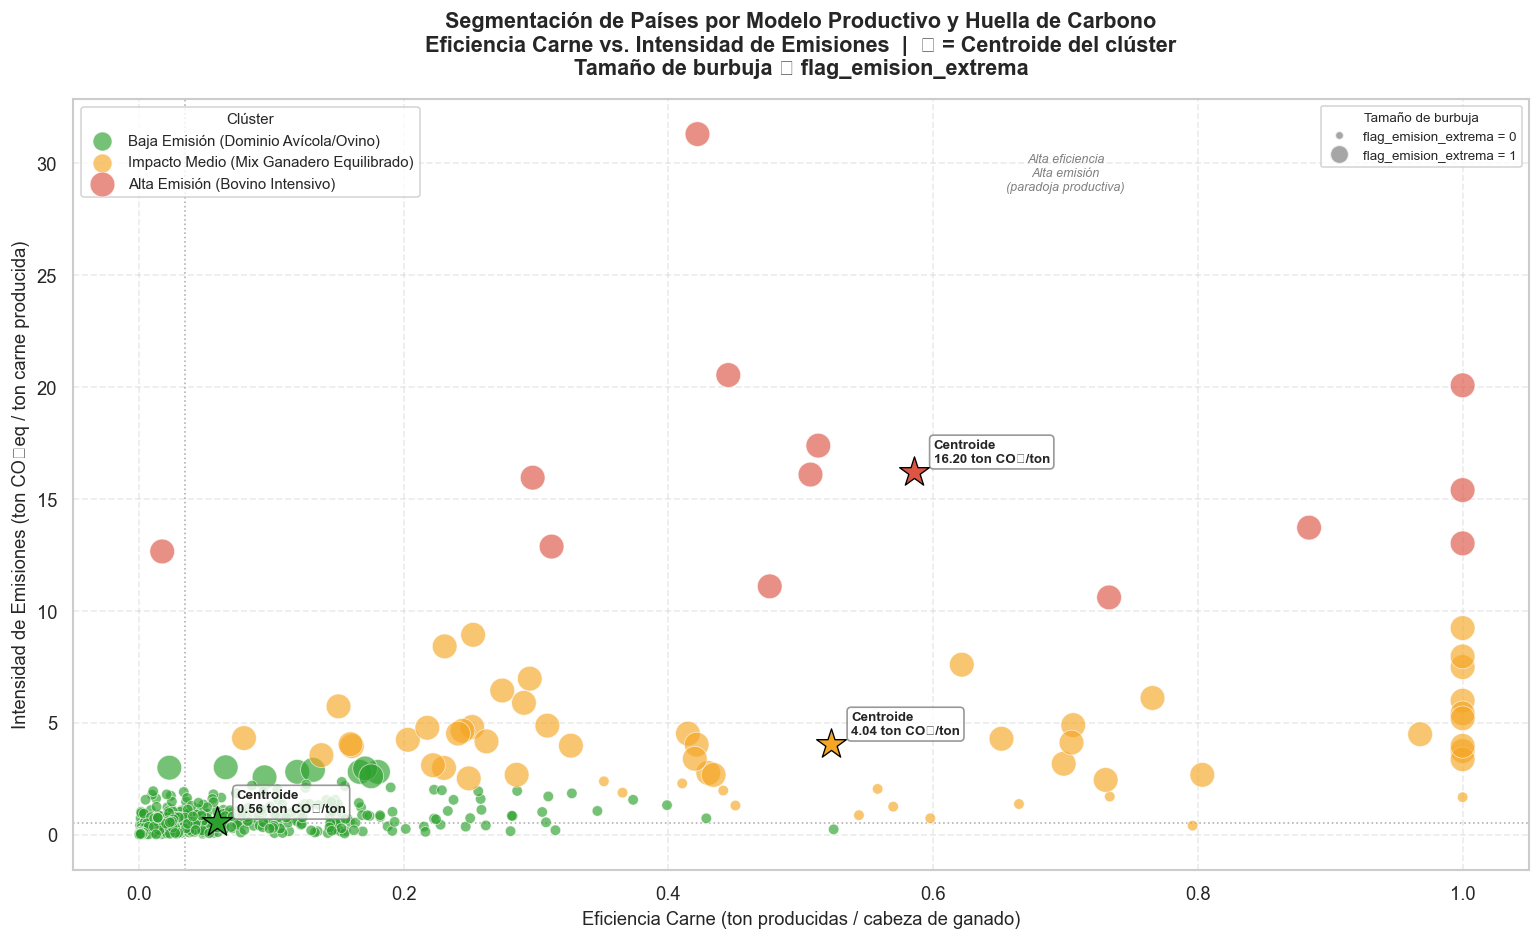

In [26]:
fig, ax = plt.subplots(figsize=(13, 8))

for cluster_id, etiqueta in etiquetas_negocio.items():
    mask = df_p3["cluster_kmeans"] == cluster_id
    sub  = df_p3[mask].copy()
    color = colores_negocio[cluster_id]

    # Tamaño de burbuja proporcional a flag_emision_extrema:
    # base 40 para todos + bonus por ser extremo
    sizes = sub["flag_emision_extrema"].map({0: 40, 1: 220})

    ax.scatter(
        sub["eficiencia_carne"],
        sub["intensidad_emisiones"],
        c=color,
        s=sizes,
        alpha=0.65,
        edgecolors="white",
        linewidths=0.5,
        label=etiqueta,
        zorder=3
    )

# Marcar centroides con estrella
for cluster_id, etiqueta in etiquetas_negocio.items():
    row = centroides[centroides["cluster_kmeans"] == cluster_id].iloc[0]
    ax.scatter(
        row["eficiencia_carne_media"],
        row["intensidad_emisiones_media"],
        c=colores_negocio[cluster_id],
        s=350, marker="*",
        edgecolors="black", linewidths=0.8,
        zorder=6
    )
    ax.annotate(
        f"Centroide\n{row['intensidad_emisiones_media']:.2f} ton CO₂/ton",
        xy=(row["eficiencia_carne_media"], row["intensidad_emisiones_media"]),
        xytext=(12, 6), textcoords="offset points",
        fontsize=8, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="gray")
    )

# Leyenda adicional para tamaño de burbuja
from matplotlib.lines import Line2D
leyenda_extra = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=5,  alpha=0.7, label='flag_emision_extrema = 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=11, alpha=0.7, label='flag_emision_extrema = 1'),
]

leg1 = ax.legend(fontsize=9, loc="upper left", title="Clúster", title_fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=leyenda_extra, fontsize=8, loc="upper right",
          title="Tamaño de burbuja", title_fontsize=8)

ax.set_title(
    "Segmentación de Países por Modelo Productivo y Huella de Carbono\n"
    "Eficiencia Carne vs. Intensidad de Emisiones  |  ★ = Centroide del clúster\n"
    "Tamaño de burbuja ∝ flag_emision_extrema",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Eficiencia Carne (ton producidas / cabeza de ganado)", fontsize=11)
ax.set_ylabel("Intensidad de Emisiones (ton CO₂eq / ton carne producida)", fontsize=11)
ax.grid(linestyle="--", alpha=0.4)

# Cuadrantes orientativos
ax.axvline(x=df_p3["eficiencia_carne"].median(), color="gray",
           linestyle=":", linewidth=1, alpha=0.6)
ax.axhline(y=df_p3["intensidad_emisiones"].median(), color="gray",
           linestyle=":", linewidth=1, alpha=0.6)
ax.text(df_p3["eficiencia_carne"].max()*0.7,
        df_p3["intensidad_emisiones"].max()*0.92,
        "Alta eficiencia\nAlta emisión\n(paradoja productiva)",
        fontsize=7.5, color="gray", style="italic", ha="center")

plt.tight_layout()
#plt.savefig("output/6_4_grafico_estrella_negocio.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# FASE 7: Guardado del Modelo para Producción
# ============================================================
import joblib
import os
import json
from datetime import datetime

# --- Directorio de destino ---
MODEL_DIR = "../../models/P3/"
os.makedirs(MODEL_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 1. Guardar el modelo K-Means entrenado
# ─────────────────────────────────────────────
joblib.dump(kmeans_final, f"{MODEL_DIR}/kmeans_k3.pkl")
print(f"✅ Modelo K-Means guardado en: {MODEL_DIR}/kmeans_k3.pkl")

# ─────────────────────────────────────────────
# 2. Guardar el scaler (CRÍTICO: mismo escalado que en entrenamiento)
# ─────────────────────────────────────────────
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")
print(f"✅ Scaler guardado en: {MODEL_DIR}/scaler.pkl")

# ─────────────────────────────────────────────
# 3. Guardar metadatos del modelo (trazabilidad)
# ─────────────────────────────────────────────
metadata = {
    "modelo": "KMeans",
    "n_clusters": 3,
    "features": list(X_scaled_df.columns),
    "silhouette_score": round(silhouette_kmeans, 4),
    "davies_bouldin": round(db_kmeans, 4),
    "inercia_wcss": round(kmeans_final.inertia_, 2),
    "n_registros_entrenamiento": len(df_p3),
    "etiquetas_negocio": etiquetas_negocio,
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "descripcion": "Segmentación de países por huella de carbono ganadera"
}

with open(f"{MODEL_DIR}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"✅ Metadatos guardados en: {MODEL_DIR}/metadata.json")

✅ Modelo K-Means guardado en: ../../models/P3//kmeans_k3.pkl
✅ Scaler guardado en: ../../models/P3//scaler.pkl
✅ Metadatos guardados en: ../../models/P3//metadata.json

🔁 Verificando carga del modelo...


KeyError: "['ganado_avicola', 'ganado_bovino', 'ganado_caprino', 'ganado_ovino', 'ganado_porcino'] not in index"

## Conclusiones Generales del Estudio de Machine Learning
### Problema 3 — Segmentación de Países por Huella de Carbono Ganadera

---

#### 1. Contexto y Objetivo

El objetivo de este estudio era encontrar grupos naturales de países/periodos
en función de su perfil de emisiones ganaderas, sin etiquetas previas
(aprendizaje no supervisado), para traducir ese resultado en recomendaciones
de política de sostenibilidad.

El dataset de partida contaba con **600 registros** y **8 variables** derivadas
del procesado del master ganadero, de las cuales las dos más discriminantes
resultaron ser `intensidad_emisiones` (ton CO₂eq/ton carne) y
`eficiencia_carne` (ton carne/cabeza).

---

#### 2. Ingeniería de Features y Preparación

Antes de entrenar ningún modelo se realizaron dos pasos críticos:

- **Escalado estándar (StandardScaler):** imprescindible en K-Means y DBSCAN,
  cuyos cálculos de distancia son sensibles a la magnitud de las variables.
  Sin escalar, `intensidad_emisiones` (rango ~0–31) dominaría completamente
  sobre variables de rango pequeño.

- **Creación de `flag_emision_extrema`:** variable binaria que marcó los 67
  registros (11.2%) con emisiones en el percentil 90 superior. Actuó como
  *ground truth* diagnóstico para validar que los clústeres capturaban
  realmente los episodios de alta contaminación.

---

#### 3. Comparativa de Modelos

Se entrenaron y evaluaron tres algoritmos con sus métricas objetivas:

| Modelo | Silhouette ↑ | Davies-Bouldin ↓ | Clústeres | Ruido | Veredicto |
|---|---|---|---|---|---|
| **K-Means k=3** | 0.6669 | 0.7470 | 3 | 0% | **ELEGIDO** |
| DBSCAN eps=1.8 | 0.7425 | 0.2958 | 2 | 4% | Partición trivial 95/1 |
| GMM n=3 | 0.2718 | 1.3465 | 3 | 0% | Sólido probabilísticamente |

**Decisión clave:** DBSCAN obtiene las mejores métricas brutas, pero su
partición (95% vs. 1%) carece de valor informativo. El Silhouette elevado
es consecuencia de una separación trivial, no de una segmentación real.
K-Means con k=3 (Silhouette=0.667, por encima del umbral de solidez de 0.5)
es el único modelo que produce **3 arquetipos equilibrados y accionables**.

> La elección del modelo en Machine Learning no es solo matemática:
> un modelo con mejores métricas pero sin utilidad de negocio no es
> el modelo correcto.

---

#### 4. Validación de k=3 — Elbow + Silhouette + Criterio de Negocio

La selección de k=3 se apoyó en tres evidencias convergentes:

- **Elbow Method:** la inercia WCSS cae bruscamente hasta k=3 y se estabiliza
  a partir de k=4, indicando que más grupos no aportan cohesión adicional.
- **Silhouette Score:** k=2 obtiene 0.814 pero produce la partición trivial
  "avicultura vs. resto"; k=3 (0.667) es la primera partición con significado
  real y calidad geométrica sólida; k=4 (0.546) fragmenta en exceso.
- **Hipótesis EDA:** el análisis exploratorio previo ya anticipaba 3 niveles
  de impacto diferenciados, confirmados por el modelo.

---

#### 5. Visualización 2D — PCA y t-SNE

La proyección PCA a 2 componentes retiene el **93.7% de la varianza original**
(PC1=81.2%, PC2=12.6%), lo que garantiza que los scatter plots son
representaciones estadísticamente fiables, no meras ilustraciones.

Los principales hallazgos visuales fueron:
- **PCA K-Means:** los 3 clústeres se separan limpiamente a lo largo de PC1
  (eje de intensidad de emisiones). El micro-clúster rojo (13 registros)
  ocupa los valores extremos de PC1 y concentra prácticamente todos los
  `flag_emision_extrema=1`.
- **t-SNE K-Means:** revela subestructura interna dentro del Clúster 0
  (mayoritario), con al menos 3 nubes locales diferenciadas. Esto sugiere
  que el dato tiene más granularidad de la que k=3 captura → **línea de
  trabajo futuro: explorar k=4 o k=5**.
- **GMM:** distribuye la dispersión interna del grupo mayoritario en 3
  componentes probabilísticas solapadas, explicando su BIC/AIC excelentes
  (-20,540 / -21,129) pese a un Silhouette bajo.

---

#### 6. Los 3 Arquetipos Ganaderos (Modelo Final)

| Arquetipo | Intensidad media | % Dataset | Alerta extrema | Especies dominantes |
|---|---|---|---|---|
| 🟢 **Baja Emisión** | 0.56 ton CO₂/ton | 88.2% | 1.7% | Avícola, Ovino |
| 🟡 **Impacto Medio** | 4.04 ton CO₂/ton | 9.7% | 77.6% | Mix Bovino+Avícola |
| 🔴 **Alta Emisión** | 16.20 ton CO₂/ton | 2.2% | 100% | Bovino Intensivo |

La intensidad de emisiones se multiplica por **7×** entre el grupo verde y
el naranja, y por **29×** entre el verde y el rojo.

---

#### 7. La Paradoja Productiva — Hallazgo Principal

El gráfico de burbujas (eficiencia_carne vs. intensidad_emisiones) confirma
el hallazgo más relevante del proyecto: **los episodios de mayor eficiencia
productiva coinciden con los de mayor intensidad de emisiones**.

Los registros del grupo 🔴 Alta Emisión se concentran en el cuadrante
superior derecho (alta eficiencia + alta contaminación). Esto demuestra que
**la intensificación productiva ganadera, en su forma actual, no es
compatible con la sostenibilidad ambiental**.

---

#### 8. Implicaciones para Políticas de Sostenibilidad

- **🟢 Grupo Baja Emisión (88%):** modelo de referencia a preservar. Las
  políticas deben incentivar que los países mantengan estructuras productivas
  basadas en avicultura y ganadería ovina.

- **🟡 Grupo Impacto Medio (9.7%):** zona crítica de intervención preventiva.
  Con un 77.6% de registros en alerta extrema, es el eslabón donde una
  política de transición tiene el mayor retorno de sostenibilidad posible.
  Alemania, Brasil e India aparecen aquí en determinados años.

- **🔴 Grupo Alta Emisión (2.2%):** episodios de contaminación severa con
  intervención correctiva urgente. Pese a representar solo el 2.2% de los
  registros, su intensidad media de 16.20 ton CO₂/ton los convierte en
  objetivos prioritarios de regulación. España, Francia, Brasil y Alemania
  aparecen en sus peores años en este grupo.

---

#### 9. Limitaciones y Líneas de Trabajo Futuro

- La subestructura detectada por t-SNE dentro del Clúster 0 sugiere que
  **k=4 o k=5** podría revelar subtipos de ganadería de baja emisión con
  perfiles distintos.
- El dataset es sintético/muestreado; con datos reales a nivel país-año
  completos, la segmentación podría refinarse incorporando variables como
  PIB agrícola, superficie de pastos o normativa medioambiental vigente.
- DBSCAN podría ser revisitado con un **preprocesado que elimine outliers
  explícitamente**, de forma que la estructura de densidad de los datos
  normales quede más limpia y el algoritmo produzca particiones con valor
  de negocio.